In [5]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
data = {
    "date": [
        "2025-01-01","2025-01-02","2025-01-03","2025-01-04","2025-01-05",
        "2025-01-06","2025-01-07","2025-01-08","2025-01-09","2025-01-10"
    ],
    "bitcoin": [42000,42500,41800,43000,43500,44000,43800,44200,44500,44800],
    "oil": [72,73,71,74,75,76,74,77,78,79],
    "sp500": [4700,4725,4690,4750,4780,4800,4790,4820,4850,4875]
}

df = pd.DataFrame(data)
df["date"] = pd.to_datetime(df["date"])

df

In [3]:
data = {
    "date": [
        "2025-01-01","2025-01-02","2025-01-03","2025-01-04","2025-01-05",
        "2025-01-06","2025-01-07","2025-01-08","2025-01-09","2025-01-10"
    ],
    "bitcoin": [42000,42500,41800,43000,43500,44000,43800,44200,44500,44800],
    "oil": [72,73,71,74,75,76,74,77,78,79],
    "sp500": [4700,4725,4690,4750,4780,4800,4790,4820,4850,4875]
}

df = pd.DataFrame(data)
df["date"] = pd.to_datetime(df["date"])

df

,date,bitcoin,oil,sp500
0,2025-01-01,42000,72,4700
1,2025-01-02,42500,73,4725
2,2025-01-03,41800,71,4690
3,2025-01-04,43000,74,4750
4,2025-01-05,43500,75,4780
5,2025-01-06,44000,76,4800
6,2025-01-07,43800,74,4790
7,2025-01-08,44200,77,4820
8,2025-01-09,44500,78,4850
9,2025-01-10,44800,79,4875


In [4]:
df[["bitcoin", "oil", "sp500"]].describe()

,bitcoin,oil,sp500
count,10.000000,10.000000,10.000000
mean,43410.000000,74.900000,4778.000000
std,1045.041201,2.601282,61.833109
min,41800.000000,71.000000,4690.000000
25%,42625.000000,73.250000,4731.250000
50%,43650.000000,74.500000,4785.000000
75%,44150.000000,76.750000,4815.000000
max,44800.000000,79.000000,4875.000000


In [6]:
conn = sqlite3.connect(":memory:")
df.to_sql("market", conn, index=False, if_exists="replace")

10

In [7]:
pd.read_sql_query("SELECT * FROM market ORDER BY bitcoin DESC LIMIT 5", conn)

,date,bitcoin,oil,sp500
0,2025-01-10 00:00:00,44800,79,4875
1,2025-01-09 00:00:00,44500,78,4850
2,2025-01-08 00:00:00,44200,77,4820
3,2025-01-06 00:00:00,44000,76,4800
4,2025-01-07 00:00:00,43800,74,4790


In [8]:
pd.read_sql_query("""
SELECT 
    AVG(bitcoin) AS avg_bitcoin,
    AVG(oil) AS avg_oil,
    AVG(sp500) AS avg_sp500
FROM market
""", conn)

,avg_bitcoin,avg_oil,avg_sp500
0,43410.0,74.9,4778.0


In [9]:
pd.read_sql_query("SELECT * FROM market ORDER BY date DESC LIMIT 1", conn)

,date,bitcoin,oil,sp500
0,2025-01-10 00:00:00,44800,79,4875


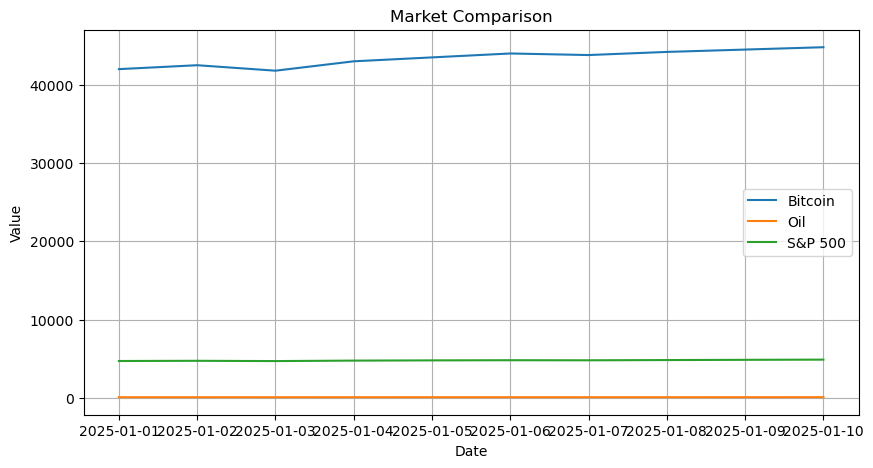

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df["date"], df["bitcoin"], label="Bitcoin")
plt.plot(df["date"], df["oil"], label="Oil")
plt.plot(df["date"], df["sp500"], label="S&P 500")
plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Market Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
df[["bitcoin", "oil", "sp500"]].corr()

,bitcoin,oil,sp500
bitcoin,1.000000,0.960925,0.989918
oil,0.960925,1.000000,0.979547
sp500,0.989918,0.979547,1.000000


In [12]:
conn.close()